<a href="https://colab.research.google.com/github/slaimrayane/Analyse-Polarisation/blob/main/Projet_Fondements.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Partie 1 - Votantes, Candidates, et Bulletins de Vote

**Question 1. Implémenter une méthode permettant de générer aléatoirement un profil dans A^n**

**Question 2. Implémenter une méthode permettant de générer aléatoirement un profil dans L^n**

In [1]:
import random
from typing import List, Optional


def validate_even(n: int, m: int) -> None:
    """
    Verifie que n et m sont pairs.

    Parametres :
        n : nombre de votantes
        m : nombre de candidates

    Leve une ValueError si n ou m est impair,
    car l'enonce impose que n et m soient pairs
    (pour pouvoir diviser en deux clusters egaux)
    """
    if n % 2 != 0:
        raise ValueError("n doit etre pair")
    if m % 2 != 0:
        raise ValueError("m doit etre pair")


# ============================================================
# PARTIE 1 : VOTES PAR APPROBATION
# Un bulletin est un vecteur de 0/1 de taille m
# ============================================================

ApprovalBallot = List[int]              # Les votes
ApprovalProfile = List[ApprovalBallot]  # Ensemble des bulletins


def random_approval_ballot(m: int, approval_prob: float = 0.5) -> ApprovalBallot:
    """
    Genere un bulletin d'approbation aleatoire.

    Pour chaque candidate, on tire un nombre aleatoire entre 0 et 1.
    Si ce nombre est inferieur a approval_prob, la candidate est approuvee (1),
    sinon elle ne l'est pas (0).

    Parametres :
        m            : nombre de candidates
        approval_prob: probabilite qu'une candidate soit approuvee (defaut : 0.5)

    Retourne :
        Un bulletin d'approbation de taille m (liste de 0 et de 1)
    """
    return [1 if random.random() < approval_prob else 0 for _ in range(m)]


def opposite_approval_ballot(ballot: ApprovalBallot) -> ApprovalBallot:
    """
    Renvoie le bulletin oppose : 1 devient 0, et 0 devient 1.

    Correspond au bulletin 'a_barre' de l'enonce, defini par :
        a_barre[j] = 1 - a[j], pour tout j

    Parametres :
        ballot : un bulletin d'approbation

    Retourne :
        Le bulletin oppose
    """
    return [1 - x for x in ballot]


def mutate_approval_ballot(ballot: ApprovalBallot, noise: float) -> ApprovalBallot:
    """
    Ajoute du bruit a un bulletin d'approbation.

    Chaque case du bulletin est inversee avec une probabilite noise.
    Cela permet de generer des bulletins proches d'un modele,
    sans etre identiques (simulation de variations individuelles).

    Parametres :
        ballot : le bulletin de reference
        noise  : probabilite qu'une case soit inversee (entre 0 et 1)

    Retourne :
        Un nouveau bulletin legerement different du bulletin original
    """
    new_ballot = ballot.copy()
    for i in range(len(new_ballot)):
        if random.random() < noise:
            new_ballot[i] = 1 - new_ballot[i]
    return new_ballot


def generate_approval_profile(
    n: int,
    m: int,
    polarization: float,
    noise: float = 0.05,
    approval_prob: float = 0.5
) -> ApprovalProfile:
    """
    Genere un profil dans A^n avec un niveau de polarisation controle.
    Repond a la Question 1 de l'enonce.

    Idee :
        - On tire un bulletin central a aleatoirement
        - On construit son oppose a_barre (1 - a)
        - On cree deux clusters de votantes :
            * Cluster 1 : votantes proches de a
            * Cluster 2 : votantes proches de a_barre
        - La taille du cluster 2 depend de polarization

    Cas extremes :
        - polarization = 0  -> tout le monde vote proche de a     -> proche de p_a
        - polarization = 1  -> moitie vote a, moitie vote a_barre -> proche de p_{a, a_barre}

    Parametres :
        n            : nombre de votantes (doit etre pair)
        m            : nombre de candidates (doit etre pair)
        polarization : niveau de polarisation entre 0 (faible) et 1 (fort)
        noise        : niveau de bruit sur chaque bulletin (defaut : 0.05)
        approval_prob: probabilite d'approbation du bulletin central (defaut : 0.5)

    Retourne :
        Un profil de n bulletins d'approbation melanges aleatoirement
    """
    validate_even(n, m)

    if not (0.0 <= polarization <= 1.0):
        raise ValueError("Attention ! La polarisation doit etre entre 0 et 1")
    if not (0.0 <= noise <= 1.0):
        raise ValueError("Attention ! Le bruit doit etre entre 0 et 1")
    if not (0.0 <= approval_prob <= 1.0):
        raise ValueError("approval_prob doit etre entre 0 et 1")

    # Bulletin de reference et son oppose
    a = random_approval_ballot(m, approval_prob=approval_prob)
    a_opposite = opposite_approval_ballot(a)

    # Nombre de votantes dans le second cluster
    # polarization=0 -> 0 votante dans le cluster oppose
    # polarization=1 -> n/2 votantes dans le cluster oppose
    second_cluster_size = int((n // 2) * polarization)
    first_cluster_size = n - second_cluster_size

    profile = []

    # Premier cluster : votantes proches de a
    for _ in range(first_cluster_size):
        profile.append(mutate_approval_ballot(a, noise))

    # Second cluster : votantes proches de a_barre
    for _ in range(second_cluster_size):
        profile.append(mutate_approval_ballot(a_opposite, noise))

    random.shuffle(profile)  # On melange les bulletins
    return profile


# ============================================================
# PARTIE 2 : VOTES PAR ORDRES TOTAUX
# Un bulletin est une permutation de [0, 1, ..., m-1]
# Exemple : [2, 0, 1, 3] signifie : 2 > 0 > 1 > 3
# ============================================================

Ranking = List[int]             # Un classement : permutation de [0, ..., m-1]
RankingProfile = List[Ranking]  # Un profil : liste de classements


def random_ranking(m: int) -> Ranking:
    """
    Genere un ordre total aleatoire sur m candidates.

    Parametres :
        m : nombre de candidates

    Retourne :
        Une permutation aleatoire de [0, 1, ..., m-1]
    """
    ranking = list(range(m))
    random.shuffle(ranking)  # Melange aleatoirement les elements de la liste
    return ranking


def opposite_ranking(ranking: Ranking) -> Ranking:
    """
    Renvoie l'ordre oppose : on inverse completement le classement.

    Correspond au classement 'r_barre' de l'enonce, defini par :
        r_barre(c) = m - r(c) + 1, pour toute candidate c

    Parametres :
        ranking : un classement de candidates

    Retourne :
        Le classement completement inverse
    """
    return ranking[::-1]


def mutate_ranking_by_swaps(ranking: Ranking, nb_swaps: int) -> Ranking:
    """
    Ajoute du bruit a un ordre total en effectuant nb_swaps echanges aleatoires.

    Contrairement aux bulletins d'approbation, on ne peut pas inverser
    des cases independamment (il faut rester une permutation valide).
    On effectue donc des echanges de paires de positions.

    Parametres :
        ranking  : le classement de reference
        nb_swaps : nombre d'echanges aleatoires a effectuer

    Retourne :
        Un nouveau classement legerement different du classement original
    """
    new_ranking = ranking.copy()
    m = len(new_ranking)

    for _ in range(nb_swaps):
        i, j = random.sample(range(m), 2)  # Choisir 2 positions differentes au hasard
        new_ranking[i], new_ranking[j] = new_ranking[j], new_ranking[i]

    return new_ranking


def generate_ranking_profile(
    n: int,
    m: int,
    polarization: float,
    noise: float = 0.05
) -> RankingProfile:

    """
    Genere un profil dans L^n avec un niveau de polarisation controle.
    Repond a la Question 2 de l'enonce.

    Idee :
        - On tire un classement central r aleatoirement
        - On construit son oppose r_barre (classement inverse)
        - On cree deux clusters de votantes :
            * Cluster 1 : votantes proches de r
            * Cluster 2 : votantes proches de r_barre
        - Le bruit est simule par des echanges aleatoires de positions

    Cas extremes :
        - polarization = 0  -> tout le monde vote proche de r     -> proche de p_r
        - polarization = 1  -> moitie vote r, moitie vote r_barre -> proche de p_{r, r_barre}

    Parametres :
        n            : nombre de votantes (doit etre pair)
        m            : nombre de candidates (doit etre pair)
        polarization : niveau de polarisation entre 0 (faible) et 1 (fort)
        noise        : niveau de bruit, converti en nombre d'echanges (defaut : 0.05)

    Retourne :
        Un profil de n classements melanges aleatoirement
    """
    validate_even(n, m)

    if not (0.0 <= polarization <= 1.0):
        raise ValueError("La polarisation doit etre entre 0 et 1")
    if not (0.0 <= noise <= 1.0):
        raise ValueError("Le bruit doit etre entre 0 et 1")

    # Classement de reference et son oppose
    central_ranking = random_ranking(m)
    opposite = opposite_ranking(central_ranking)

    # Calcul de la taille des deux clusters
    second_cluster_size = int((n // 2) * polarization)
    first_cluster_size = n - second_cluster_size

    # Conversion du bruit en nombre d'echanges
    # Plus noise est grand, plus on deforme les classements
    max_swaps = max(1, m // 2)
    nb_swaps = int(noise * max_swaps)

    profile = []

    # Premier cluster : votantes proches du classement central
    for _ in range(first_cluster_size):
        profile.append(mutate_ranking_by_swaps(central_ranking, nb_swaps))

    # Second cluster : votantes proches du classement oppose
    for _ in range(second_cluster_size):
        profile.append(mutate_ranking_by_swaps(opposite, nb_swaps))

    random.shuffle(profile)  # Melange pour ne pas grouper les clusters
    return profile

In [2]:
# ============================================================
# PARTIE 2 : VOTES PAR ORDRES TOTAUX
# Un bulletin est une permutation de [0, 1, ..., m-1]
# Exemple : [2, 0, 1, 3]
# Cela signifie : 2 > 0 > 1 > 3
# ============================================================

Ranking = List[int]              # Un classement : permutation de [0, ..., m-1]
RankingProfile = List[Ranking]   # Un profil : liste de classements


def random_ranking(m: int) -> Ranking:
    """
    Genere un ordre total aleatoire sur m candidates.

    Parametres :
        m : nombre de candidates

    Retourne :
        Une permutation aleatoire de [0, 1, ..., m-1]

    Exemple :
        random_ranking(4) -> [2, 0, 3, 1]
    """
    ranking = list(range(m))
    random.shuffle(ranking) # Melange aléatoirement les éléments d'une liste, directement dans la liste
    return ranking


def opposite_ranking(ranking: Ranking) -> Ranking:
    """
    Renvoie l'ordre oppose : on inverse completement le classement.

    Correspond au classement 'r_barre' de l'enonce, defini par :
        r_barre(c) = m - r(c) + 1, pour toute candidate c

    Parametres :
        ranking : un classement de candidates

    Retourne :
        Le classement completement inverse

    Exemple :
        opposite_ranking([2, 0, 3, 1]) -> [1, 3, 0, 2]
    """
    return ranking[::-1]


def mutate_ranking_by_swaps(ranking: Ranking, nb_swaps: int) -> Ranking:
    """
    Renvoie l'ordre oppose : on inverse completement le classement.

    Correspond au classement 'r_barre' de l'enonce, defini par :
        r_barre(c) = m - r(c) + 1, pour toute candidate c

    Parametres :
        ranking : un classement de candidates

    Retourne :
        Le classement completement inverse

    Exemple :
        opposite_ranking([2, 0, 3, 1]) -> [1, 3, 0, 2]
    """
    new_ranking = ranking.copy()
    m = len(new_ranking)

    for _ in range(nb_swaps):
        i, j = random.sample(range(m), 2) # choisir plusieurs elements au hasard SANS rep
        new_ranking[i], new_ranking[j] = new_ranking[j], new_ranking[i]

    return new_ranking


def generate_ranking_profile(
    n: int,
    m: int,
    polarization: float,
    noise: float = 0.05

) -> RankingProfile:
    """
    Genere un profil dans L^n avec un niveau de polarisation controle.
    Repond a la Question 2 de l'enonce.

    Idee :
        - On tire un classement central r aleatoirement
        - On construit son oppose r_barre (classement inverse)
        - On cree deux clusters de votantes :
            * Cluster 1 : votantes proches de r
            * Cluster 2 : votantes proches de r_barre
        - Le bruit est simule par des echanges aleatoires de positions

    Cas extremes :
        - polarization = 0  -> tout le monde vote proche de r    -> proche de p_r
        - polarization = 1  -> moitie vote r, moitie vote r_barre -> proche de p_{r, r_barre}

    Parametres :
        n            : nombre de votantes (doit etre pair)
        m            : nombre de candidates (doit etre pair)
        polarization : niveau de polarisation entre 0 (faible) et 1 (fort)
        noise        : niveau de bruit, converti en nombre d'echanges (defaut : 0.05)

    Retourne :
        Un profil de n classements melanges aleatoirement
    """


    validate_even(n, m)

    if not (0.0 <= polarization <= 1.0):
        raise ValueError("La polarisation doit etre entre 0 et 1")
    if not (0.0 <= noise <= 1.0):
        raise ValueError("Le bruit doit etre entre 0 et 1")

    #Classement de reference et son oppose

    central_ranking = random_ranking(m)
    opposite = opposite_ranking(central_ranking)

    #Calcul de la taille des deux clusters
    second_cluster_size = int((n // 2) * polarization)
    first_cluster_size = n - second_cluster_size

    # On convertit noise en nombre d'echanges
    # Plus noise est grand, plus on deforme les classements
    max_swaps = max(1, m // 2)
    nb_swaps = int(noise * max_swaps)

    profile = []

    # Premier cluster : votantes proches du classement central
    for _ in range(first_cluster_size):
        profile.append(mutate_ranking_by_swaps(central_ranking, nb_swaps))

    # Second cluster : votantes proches du classement oppose
    for _ in range(second_cluster_size):
        profile.append(mutate_ranking_by_swaps(opposite, nb_swaps))

    random.shuffle(profile)     # Melange pour ne pas grouper les clusters
    return profile

In [3]:
N = 10
M = 6

# ============================================================
# AFFICHAGE
# ============================================================

def afficher_profil_approbation(profil, titre):
    """Affiche un profil de votes par approbation de façon lisible."""
    print(f"\n{'='*50}")
    print(f"  {titre}")
    print(f"{'='*50}")
    print(f"  {N} votantes | {M} candidates\n")
    for i, bulletin in enumerate(profil):
        approuvees = [j + 1 for j, v in enumerate(bulletin) if v == 1]
        print(f"  Votante {i+1:2} : {bulletin}  -> approuve candidates {approuvees}")
    print()


def afficher_profil_ranking(profil, titre):
    """Affiche un profil de votes par ordres totaux de façon lisible."""
    print(f"\n{'='*50}")
    print(f"  {titre}")
    print(f"{'='*50}")
    print(f"  {N} votantes | {M} candidates\n")
    for i, classement in enumerate(profil):
        ordre = " > ".join(f"c{c+1}" for c in classement)
        classement_affiche = [c+1 for c in classement]
        print(f"  Votante {i+1:2} : {classement_affiche}  -> {ordre}")
    print()

**MAIN : partie 1**

In [4]:
if __name__ == "__main__":

    print("\n" + "#"*50)
    print("#   VOTES PAR APPROBATION")
    print("#"*50)

    # Faible polarisation
    p1 = generate_approval_profile(N, M, polarization=0.0, noise=0.05)
    afficher_profil_approbation(p1, "Polarisation minimale (0.0) -> proche de p_a")

    # Polarisation moyenne
    p2 = generate_approval_profile(N, M, polarization=0.5, noise=0.05)
    afficher_profil_approbation(p2, "Polarisation moyenne (0.5)")

    # Forte polarisation
    p3 = generate_approval_profile(N, M, polarization=1.0, noise=0.05)
    afficher_profil_approbation(p3, "Polarisation maximale (1.0) -> proche de p_{a, ā}")


    print("\n" + "#"*50)
    print("#   VOTES PAR ORDRES TOTAUX")
    print("#"*50)

    # Faible polarisation
    p4 = generate_ranking_profile(N, M, polarization=0.0, noise=0.05)
    afficher_profil_ranking(p4, "Polarisation minimale (0.0) -> proche de p_≽")

    # Polarisation moyenne
    p5 = generate_ranking_profile(N, M, polarization=0.5, noise=0.05)
    afficher_profil_ranking(p5, "Polarisation moyenne (0.5)")

    # Forte polarisation
    p6 = generate_ranking_profile(N, M, polarization=1.0, noise=0.05)
    afficher_profil_ranking(p6, "Polarisation maximale (1.0) -> proche de p_{≽, ≽̄}")


##################################################
#   VOTES PAR APPROBATION
##################################################

  Polarisation minimale (0.0) -> proche de p_a
  10 votantes | 6 candidates

  Votante  1 : [1, 1, 0, 0, 1, 1]  -> approuve candidates [1, 2, 5, 6]
  Votante  2 : [1, 1, 0, 0, 1, 1]  -> approuve candidates [1, 2, 5, 6]
  Votante  3 : [1, 1, 0, 0, 1, 1]  -> approuve candidates [1, 2, 5, 6]
  Votante  4 : [1, 1, 0, 0, 1, 1]  -> approuve candidates [1, 2, 5, 6]
  Votante  5 : [1, 1, 0, 0, 1, 1]  -> approuve candidates [1, 2, 5, 6]
  Votante  6 : [1, 0, 0, 0, 1, 1]  -> approuve candidates [1, 5, 6]
  Votante  7 : [1, 1, 0, 0, 1, 1]  -> approuve candidates [1, 2, 5, 6]
  Votante  8 : [1, 1, 0, 0, 1, 1]  -> approuve candidates [1, 2, 5, 6]
  Votante  9 : [1, 1, 0, 0, 1, 1]  -> approuve candidates [1, 2, 5, 6]
  Votante 10 : [1, 1, 0, 0, 1, 1]  -> approuve candidates [1, 2, 5, 6]


  Polarisation moyenne (0.5)
  10 votantes | 6 candidates

  Votante  1 : [1, 0, 1, 

# Partie 2 – Axiomes sur la Polarisation

Cette partie implémente et étudie la mesure de polarisation φ².

**Plan :**
- Q3 : Calcul des d_ckcl (réponses écrites + code)
- Q4 : Axiomes vérifiés par φ² (réponses écrites)
- Q5 : Implémentation de φ²
- Q6 : Tracé de l'évolution de φ²

## Question 3 – Calcul des d_ckcl

Pour chaque paire de candidats (ck, cl), on calcule la différence absolue
entre le nombre de votantes préférant ck à cl et celles préférant cl à ck.




In [5]:
from itertools import combinations

def calculer_d_approbation(profil, m):
    """
    Calcule les d_ckcl pour un profil de votes par approbation.
    profil : liste de vecteurs binaires ex: [[1,0,1], [0,1,0]]
    m : nombre de candidats
    """
    resultats = {}
    for (ck, cl) in combinations(range(m), 2):
        n_ck_cl = 0
        n_cl_ck = 0
        for bulletin in profil:
            if bulletin[ck] == 1 and bulletin[cl] == 0:
                n_ck_cl += 1
            elif bulletin[cl] == 1 and bulletin[ck] == 0:
                n_cl_ck += 1
        d = abs(n_ck_cl - n_cl_ck)
        resultats[(ck, cl)] = d
    return resultats


def calculer_d_ordres(profil, m):
    """
    Calcule les d_ckcl pour un profil de votes par ordres totaux.
    profil : liste de classements ex: [[2,0,1], [1,0,2]]
    m : nombre de candidats
    """
    resultats = {}
    for (ck, cl) in combinations(range(m), 2):
        n_ck_cl = 0
        n_cl_ck = 0
        for bulletin in profil:
            rang = [0] * m
            for position, candidat in enumerate(bulletin):
                rang[candidat] = position
            if rang[ck] < rang[cl]:
                n_ck_cl += 1
            elif rang[cl] < rang[ck]:
                n_cl_ck += 1
        d = abs(n_ck_cl - n_cl_ck)
        resultats[(ck, cl)] = d
    return resultats


# ici c'est les tests
profil_app = [[1,0,0],[1,0,0],[0,1,1],[0,1,1]]
print("=== Test approbation ===")
for paire, val in calculer_d_approbation(profil_app, m=3).items():
    print(f"  d{paire} = {val}")

profil_ord = [[0,1,2],[0,1,2],[2,1,0],[2,1,0]]
print("\n=== Test ordres totaux ===")
for paire, val in calculer_d_ordres(profil_ord, m=3).items():
    print(f"  d{paire} = {val}")

=== Test approbation ===
  d(0, 1) = 0
  d(0, 2) = 0
  d(1, 2) = 0

=== Test ordres totaux ===
  d(0, 1) = 0
  d(0, 2) = 0
  d(1, 2) = 0


## Question 4 – Axiomes vérifiés par φ²

On étudie si φ² vérifie les 4 axiomes : Régularité, Neutralité, Anonymité,
et Invariance par réplication.

**Axiome 1 – Régularité **
φ²(p) ∈ [0,1] car chaque terme (n - d_ckcl) / n est dans [0,1]
et on fait une moyenne de ces termes.
- φ²(p) = 0 ssi tous les d_ckcl = n, ce qui arrive ssi tout le monde vote pareil → p = p_a
- φ²(p) = 1 ssi tous les d_ckcl = 0, ce qui arrive ssi pour chaque paire
  exactement la moitié préfère ck et l'autre moitié préfère cl → p = p_{a,ā}

**Axiome 2 – Neutralité **
Permuter les candidates par π permute les paires (ck, cl) mais ne change pas
l'ensemble des valeurs {d_ckcl}. La somme reste donc identique → φ²(p^π) = φ²(p)

**Axiome 3 – Anonymité **
Permuter les votantes par σ ne change pas les comptages n_ckcl ni n_clck
car on compte juste le nombre de votantes avec une certaine préférence → φ²(σp) = φ²(p)

**Axiome 4 – Invariance par réplication **
Pour kp, chaque d_ckcl est multiplié par k, et n aussi.
Donc (kn - k*d_ckcl) / kn = (n - d_ckcl) / n → φ²(kp) = φ²(p)

## Question 5 – Implémentation de φ²

φ²(p) = Σ_{(ck,cl) ∈ C²} (n - d_ckcl(p)) / (n × C(m,2))

où C(m,2) = m(m-1)/2 est le nombre de paires de candidats.

In [6]:
def phi2_approbation(profil, m):
    """
    Calcule phi2 pour un profil de votes par approbation.
    """
    n = len(profil)
    d_values = calculer_d_approbation(profil, m)
    nb_paires = m * (m - 1) / 2
    somme = sum((n - d) / n for d in d_values.values())
    return somme / nb_paires


def phi2_ordres(profil, m):
    """
    Calcule phi2 pour un profil de votes par ordres totaux.
    """
    n = len(profil)
    d_values = calculer_d_ordres(profil, m)
    nb_paires = m * (m - 1) / 2
    somme = sum((n - d) / n for d in d_values.values())
    return somme / nb_paires



profil_min = [[1,0],[1,0],[1,0],[1,0]]
profil_max = [[1,0],[1,0],[0,1],[0,1]]
profil_ord_min = [[0,1,2],[0,1,2],[0,1,2],[0,1,2]]
profil_ord_max = [[0,1,2],[0,1,2],[2,1,0],[2,1,0]]

print("=== Test phi2 approbation ===")
print(f"  phi2(min) = {phi2_approbation(profil_min, m=2)}")
print(f"  phi2(max) = {phi2_approbation(profil_max, m=2)}")

print("\n=== Test phi2 ordres totaux ===")
print(f"  phi2(min) = {phi2_ordres(profil_ord_min, m=3)}")
print(f"  phi2(max) = {phi2_ordres(profil_ord_max, m=3)}")

=== Test phi2 approbation ===
  phi2(min) = 0.0
  phi2(max) = 1.0

=== Test phi2 ordres totaux ===
  phi2(min) = 0.0
  phi2(max) = 1.0


## Question 6 – Tracé de l'évolution de φ²

On trace φ² en fonction du niveau de polarisation en utilisant les fonctions
de génération de profils de la Partie 1 (Q1 et Q2).
Pour chaque niveau, on génère 30 profils et on fait la moyenne pour lisser
les variations aléatoires.

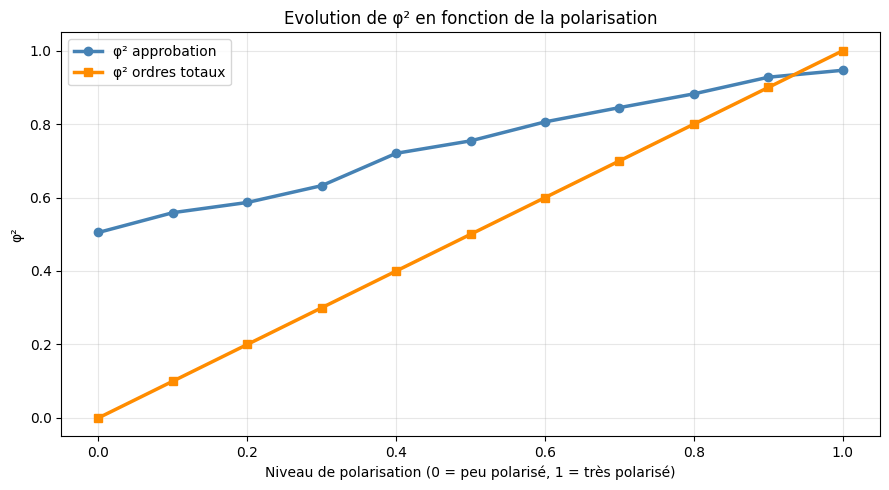

Figure sauvegardée : phi2_evolution.png


In [7]:
import numpy as np
import matplotlib.pyplot as plt

niveaux = np.linspace(0, 1, 11)
phi2_app_valeurs = []
phi2_rank_valeurs = []

for pol in niveaux:
    vals_app = []
    vals_rank = []
    for _ in range(30):
        # Approbation - fonction de la Partie 1
        p_app = generate_approval_profile(n=20, m=4, polarization=pol, noise=0.05)
        vals_app.append(phi2_approbation(p_app, m=4))

        # Ordres totaux - fonction de la Partie 1
        p_rank = generate_ranking_profile(n=20, m=4, polarization=pol, noise=0.05)
        vals_rank.append(phi2_ordres(p_rank, m=4))

    phi2_app_valeurs.append(np.mean(vals_app))
    phi2_rank_valeurs.append(np.mean(vals_rank))

plt.figure(figsize=(9, 5))
plt.plot(niveaux, phi2_app_valeurs, marker='o', color='steelblue',
         linewidth=2.5, label='φ² approbation')
plt.plot(niveaux, phi2_rank_valeurs, marker='s', color='darkorange',
         linewidth=2.5, label='φ² ordres totaux')
plt.xlabel("Niveau de polarisation (0 = peu polarisé, 1 = très polarisé)")
plt.ylabel("φ²")
plt.title("Evolution de φ² en fonction de la polarisation")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('phi2_evolution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure sauvegardée : phi2_evolution.png")

# Partie 3 – Distances et Mesures de Polarisation

Cette partie implémente et étudie des mesures de polarisation basées sur des distances entre bulletins de vote.

**Plan :**
- Q7 : Preuves que dH et dS sont des distances (réponses écrites)
- Q8 : Implémentation de dH et dS
- Q9 : Axiomes vérifiés par φ_dH (réponses écrites)
- Q10 : Calcul efficace de u*1 pour votes par approbations
- Q11 : Calcul efficace de u*1 pour votes par ordres totaux
- Q12 : Implémentation de u*1
- Q13 : Implémentation de u*2 via k-means
- Q14 : Implémentation de φ_dH et φ_dS
- Q15 : Tracé de l'évolution des mesures en fonction de la polarisation

---
## Question 7 – dH et dS sont des distances

### Distance de Hamming dH

Soient `a, a' ∈ A = {0,1}^m`. On définit `dH(a, a') = Σ_{i=1}^{m} 1_{a[i] ≠ a'[i]}`.

**1. Positivité :** `dH(a, a') ≥ 0` car c'est une somme d'indicateurs valant 0 ou 1. ✓

**2. Séparation :**
- Si `a = a'`, alors `a[i] = a'[i]` pour tout `i`, donc `dH(a, a') = 0`.
- Si `dH(a, a') = 0`, alors `1_{a[i] ≠ a'[i]} = 0` pour tout `i`, donc `a[i] = a'[i]` pour tout `i`, donc `a = a'`. ✓

**3. Symétrie :** `1_{a[i] ≠ a'[i]} = 1_{a'[i] ≠ a[i]}`, donc `dH(a, a') = dH(a', a)`. ✓

**4. Inégalité triangulaire :** Pour tout `a, a', a'' ∈ A` :
Pour chaque `i`, si `a[i] ≠ a''[i]`, alors soit `a[i] ≠ a'[i]`, soit `a'[i] ≠ a''[i]` (ou les deux).
Donc `1_{a[i]≠a''[i]} ≤ 1_{a[i]≠a'[i]} + 1_{a'[i]≠a''[i]}`.
En sommant sur `i` : `dH(a, a'') ≤ dH(a, a') + dH(a', a'')`. ✓

---

### Distance de Spearman dS

Soient `≺_k, ≺_l ∈ L` avec fonctions de rang `r_k, r_l : C → {1,...,m}`.
On définit `dS(≺_k, ≺_l) = Σ_{i=1}^{m} |r_k(i) - r_l(i)|`.

**1. Positivité :** `dS(≺_k, ≺_l) ≥ 0` car somme de valeurs absolues. ✓

**2. Séparation :**
- Si `≺_k = ≺_l`, alors `r_k(i) = r_l(i)` pour tout `i`, donc `dS = 0`.
- Si `dS = 0`, alors `|r_k(i) - r_l(i)| = 0` pour tout `i`, donc `r_k(i) = r_l(i)` pour tout `i`, donc `≺_k = ≺_l`. ✓

**3. Symétrie :** `|r_k(i) - r_l(i)| = |r_l(i) - r_k(i)|`, donc `dS(≺_k, ≺_l) = dS(≺_l, ≺_k)`. ✓

**4. Inégalité triangulaire :** Par l'inégalité triangulaire sur les valeurs absolues réelles :
`|r_k(i) - r_l(i)| ≤ |r_k(i) - r_j(i)| + |r_j(i) - r_l(i)|`.
En sommant sur `i` : `dS(≺_k, ≺_l) ≤ dS(≺_k, ≺_j) + dS(≺_j, ≺_l)`. ✓

---
## Imports

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import linear_sum_assignment

rng = np.random.default_rng(42)

---
## Rappel : Génération des profils (Questions 1 & 2)

On réutilise ici les générateurs de profils définis dans la partie précédente.

**Stratégie de contrôle de la polarisation :**
- On fixe un bulletin de référence `a` (ou ordre `≺`) tiré aléatoirement.
- Son opposé `ā` est le bulletin symétrique.
- Chaque votante tire indépendamment :
  - avec proba `(1 - alpha)` : elle appartient à l'un des deux clusters (moitié choisit `a` avec bruit, moitié choisit `ā` avec bruit)
  - avec proba `alpha` : elle vote uniformément au hasard (bruit pur)
- `alpha = 0` → très polarisé ; `alpha = 1` → peu polarisé

---
## Question 8 – Implémentation des distances dH et dS

In [9]:
# ============================================================
# Q8 : Distance de Hamming et Distance de Spearman
# ============================================================

def hamming(a: ApprovalBallot, b: ApprovalBallot) -> int:
    """
    Distance de Hamming entre deux votes par approbation.
    dH(a, b) = nombre de positions où a et b diffèrent.
    """
    return sum(1 for x, y in zip(a, b) if x != y)


def spearman(r1: Ranking, r2: Ranking) -> int:
    """
    Distance de Spearman entre deux votes par ordres totaux.
    r1 et r2 sont des listes représentant l'ordre de préférence
    (r1[k] = candidate à la position k dans le classement).
    dS(r1, r2) = somme sur chaque candidate de |position_r1 - position_r2|
    """
    m = len(r1)
    # Construire la fonction de rang : rang[c] = position de la candidate c
    rang1 = {c: i for i, c in enumerate(r1)}
    rang2 = {c: i for i, c in enumerate(r2)}
    return sum(abs(rang1[c] - rang2[c]) for c in range(m))


# ── Tests rapides ──
a1 = [1, 0, 1, 0]
a2 = [0, 0, 1, 1]
print(f"dH({a1}, {a2}) = {hamming(a1, a2)}")  # attend 2

r1 = [0, 1, 2, 3]  # classement de référence : c0 > c1 > c2 > c3
r2 = [3, 2, 1, 0]  # classement inverse       : c3 > c2 > c1 > c0
print(f"dS({r1}, {r2}) = {spearman(r1, r2)}")  # attend |0-3|+|1-2|+|2-1|+|3-0| = 8

dH([1, 0, 1, 0], [0, 0, 1, 1]) = 2
dS([0, 1, 2, 3], [3, 2, 1, 0]) = 8


---
## Question 9 – Axiomes vérifiés par φ_dH

Rappel : `φ_dH(p) = (2 / (n × m)) × (u*1(p) - u*2(p))`

**Axiome 1 – Régularité :**
- `u*1(p) ≥ u*2(p)` toujours (deux centres s'ajustent mieux qu'un seul) → `φ_dH ≥ 0`.
- La borne sup `u*1 - u*2 ≤ n*m/2` donne `φ_dH ≤ 1` (atteinte pour `p_{a, ā}`).
- `φ_dH = 0` ⟺ `u*1 = u*2` ⟺ un seul centre suffit ⟺ profil non polarisé (`p_a`).
- `φ_dH = 1` ⟺ cas maximalement polarisé (`p_{a, ā}`). ✓ (sous réserve de normalisation exacte)

**Axiome 2 – Neutralité :**
Permuter les labels des candidates revient à permuter les coordonnées de chaque bulletin.
`dH` compte les positions où les bulletins diffèrent → invariant par permutation des coordonnées.
Donc `u*1(p^π) = u*1(p)` et `u*2(p^π) = u*2(p)` → `φ_dH(p^π) = φ_dH(p)`. ✓

**Axiome 3 – Anonymité :**
`u*1` et `u*2` sont des sommes sur tous les bulletins → invariantes par permutation des votantes.
Donc `φ_dH(σp) = φ_dH(p)`. ✓

**Axiome 4 – Invariance par réplication :**
Si on duplique `k` fois chaque bulletin, `u*1(kp) = k × u*1(p)` et `u*2(kp) = k × u*2(p)`.
Le profil `kp` a `k×n` votantes, donc `φ_dH(kp) = (2 / (kn × m)) × (k u*1 - k u*2) = φ_dH(p)`. ✓

---
## Question 10 – Calcul efficace de u*1 pour votes par approbation

On cherche `a* ∈ {0,1}^m` qui minimise `Σ_{a' ∈ p} dH(a, a')`.

$$\sum_{a' \in p} d_H(a, a') = \sum_{a' \in p} \sum_{j=1}^{m} \mathbf{1}_{a[j] \neq a'[j]}$$

On peut inverser les sommes :

$$= \sum_{j=1}^{m} \sum_{a' \in p} \mathbf{1}_{a[j] \neq a'[j]}$$

Chaque coordonnée `j` est **indépendante**. Pour la coordonnée `j` :
- Si on pose `a[j] = 1` → coût = nombre de bulletins où `a'[j] = 0` = `n - s_j` (où `s_j = Σ a'[j]`)
- Si on pose `a[j] = 0` → coût = nombre de bulletins où `a'[j] = 1` = `s_j`

**Décision optimale pour chaque coordonnée `j` :**
- `a*[j] = 1` si `s_j > n/2` (majorité approuve)
- `a*[j] = 0` si `s_j < n/2`
- indifférent si `s_j = n/2`

C'est le **vote majoritaire** coordonnée par coordonnée !  
Le coût optimal est `u*1 = Σ_j min(s_j, n - s_j)`.

---
## Question 11 – Calcul efficace de u*1 pour votes par ordres totaux

On cherche `≺* ∈ L` qui minimise `Σ_{≺' ∈ p} dS(≺, ≺')`.

$$\sum_{\prec' \in p} d_S(\prec, \prec') = \sum_{\prec' \in p} \sum_{j=1}^{m} |r_{\prec}(j) - r_{\prec'}(j)|$$

Contrairement au cas approbation, les coordonnées **ne sont pas indépendantes** : les rangs forment une permutation de `{1,...,m}`, on ne peut pas choisir chaque `r(j)` indépendamment.

On reformule cela comme un **problème d'affectation** :
- On cherche une bijection `σ : {1,...,m} → {1,...,m}` telle que `r*(j) = σ(j)`.
- Le coût de l'affectation est `Σ_j Σ_{≺' ∈ p} |σ(j) - r_{≺'}(j)|`.
- On définit la matrice de coût `C[j][k] = Σ_{≺' ∈ p} |k - r_{≺'}(j)|` (coût d'assigner le rang `k` à la candidate `j`).
- On résout le **couplage parfait de poids minimum** sur ce graphe biparti avec `scipy.optimize.linear_sum_assignment`.

---
## Question 12 – Implémentation de u*1

In [10]:
# ============================================================
# Q12a : u*1 pour votes par APPROBATION
# Bulletin consensus = vote majoritaire coordonnée par coordonnée
# ============================================================

def consensus_approval(profile: ApprovalProfile) -> ApprovalBallot:
    """
    Retourne le bulletin de consensus a* pour des votes par approbation.
    a*[j] = 1 si strictement plus de la moitié des votantes approuvent j, 0 sinon.
    """
    n = len(profile)
    m = len(profile[0])
    sums = [sum(profile[i][j] for i in range(n)) for j in range(m)]
    return [1 if sums[j] > n / 2 else 0 for j in range(m)]


def u_star_1_approval(profile: ApprovalProfile) -> int:
    """
    Calcule u*1(p) pour des votes par approbation.
    u*1 = Σ_j min(s_j, n - s_j)
    """
    n = len(profile)
    m = len(profile[0])
    sums = [sum(profile[i][j] for i in range(n)) for j in range(m)]
    return sum(min(sums[j], n - sums[j]) for j in range(m))


# ── Test ──
p_test = [
    [1, 0, 1],
    [1, 0, 1],
    [0, 1, 0],
    [0, 1, 0],
]
a_star = consensus_approval(p_test)
u1 = u_star_1_approval(p_test)
print(f"Bulletin consensus   : {a_star}")
print(f"u*1 (approbation)    : {u1}")

Bulletin consensus   : [0, 0, 0]
u*1 (approbation)    : 6


In [11]:
# ============================================================
# Q12b : u*1 pour votes par ORDRES TOTAUX
# Via couplage parfait de poids minimum (algorithme hongrois)
# ============================================================

def consensus_ranking(profile: RankingProfile) -> Ranking:
    """
    Retourne l'ordre de consensus ≺* minimisant la somme des distances de Spearman.
    C[c][k] = coût d'assigner la position k à la candidate c
            = Σ_{≺'∈p} |k - position de c dans ≺'|
    On résout le problème d'affectation (algorithme hongrois).
    """
    n = len(profile)
    m = len(profile[0])

    # Pour chaque bulletin, construire le tableau de positions : pos[c] = position de c
    positions = []
    for ballot in profile:
        pos = [0] * m
        for k, c in enumerate(ballot):
            pos[c] = k
        positions.append(pos)

    # Matrice de coût C[c][k]
    C = np.zeros((m, m), dtype=int)
    for c in range(m):
        for k in range(m):
            C[c][k] = sum(abs(positions[i][c] - k) for i in range(n))

    # Résolution du problème d'affectation
    row_ind, col_ind = linear_sum_assignment(C)
    # row_ind[c] = c (toutes les candidates), col_ind[c] = position assignée à c
    # On reconstruit le classement : classement[k] = candidate à la position k
    consensus = [0] * m
    for c, k in zip(row_ind, col_ind):
        consensus[k] = c
    return consensus


def u_star_1_ranking(profile: RankingProfile) -> int:
    """
    Calcule u*1(p) pour des votes par ordres totaux.
    = coût optimal du problème d'affectation
    """
    n = len(profile)
    m = len(profile[0])

    positions = []
    for ballot in profile:
        pos = [0] * m
        for k, c in enumerate(ballot):
            pos[c] = k
        positions.append(pos)

    C = np.zeros((m, m), dtype=int)
    for c in range(m):
        for k in range(m):
            C[c][k] = sum(abs(positions[i][c] - k) for i in range(n))

    row_ind, col_ind = linear_sum_assignment(C)
    return int(C[row_ind, col_ind].sum())


# ── Test ──
# Profil polarisé : moitié [0,1,2], moitié [2,1,0]
p_rank_test = [
    [0, 1, 2],
    [0, 1, 2],
    [2, 1, 0],
    [2, 1, 0],
]
c_rank = consensus_ranking(p_rank_test)
u1_rank = u_star_1_ranking(p_rank_test)
print(f"Ordre consensus         : {c_rank}")
print(f"u*1 (ordres totaux)     : {u1_rank}")

Ordre consensus         : [np.int64(0), np.int64(1), np.int64(2)]
u*1 (ordres totaux)     : 8


---
## Question 13 – Estimation de u*2 via k-means

L'algorithme k-means (k=2) cherche deux centres `ã1, ã2` minimisant la somme des distances intra-cluster.

**Étapes :**
1. Initialiser `ã1, ã2` aléatoirement.
2. Répéter jusqu'à convergence :
   - **Affectation** : chaque votante est affectée au centre le plus proche.
   - **Mise à jour** : chaque centre devient le consensus de son cluster (= u*1 du sous-profil).
3. Retourner la somme des distances intra-cluster.

On relance plusieurs fois pour se rapprocher de l'optimum global.

In [12]:
# ============================================================
# Q13a : u*2 pour votes par APPROBATION (k-means)
# ============================================================

def kmeans_approval(profile: ApprovalProfile, n_runs: int = 10) -> int:
    """
    Estime u*2(p) pour des votes par approbation via k-means (k=2).
    On relance n_runs fois et on garde le meilleur résultat.
    """
    n = len(profile)
    best_cost = float('inf')

    for _ in range(n_runs):
        # Initialisation : deux bulletins aléatoires du profil
        idx1, idx2 = random.sample(range(n), 2)
        c1 = profile[idx1].copy()
        c2 = profile[idx2].copy()

        prev_labels = None

        for _ in range(100):  # max 100 itérations
            # ── Affectation ──
            labels = []
            for v in profile:
                d1 = hamming(v, c1)
                d2 = hamming(v, c2)
                labels.append(0 if d1 <= d2 else 1)

            if prev_labels is not None and labels == prev_labels:
                break  # convergence
            prev_labels = labels[:]

            # ── Mise à jour des centres ──
            cluster1 = [profile[i] for i in range(n) if labels[i] == 0]
            cluster2 = [profile[i] for i in range(n) if labels[i] == 1]

            if cluster1:
                c1 = consensus_approval(cluster1)
            if cluster2:
                c2 = consensus_approval(cluster2)

        # ── Calcul du coût final ──
        cost1 = sum(hamming(profile[i], c1) for i in range(n) if labels[i] == 0)
        cost2 = sum(hamming(profile[i], c2) for i in range(n) if labels[i] == 1)
        total_cost = cost1 + cost2

        if total_cost < best_cost:
            best_cost = total_cost

    return best_cost


# ============================================================
# Q13b : u*2 pour votes par ORDRES TOTAUX (k-means)
# ============================================================

def kmeans_ranking(profile: RankingProfile, n_runs: int = 10) -> int:
    """
    Estime u*2(p) pour des votes par ordres totaux via k-means (k=2).
    On relance n_runs fois et on garde le meilleur résultat.
    """
    n = len(profile)
    best_cost = float('inf')

    for _ in range(n_runs):
        # Initialisation : deux ordres aléatoires du profil
        idx1, idx2 = random.sample(range(n), 2)
        c1 = profile[idx1].copy()
        c2 = profile[idx2].copy()

        prev_labels = None

        for _ in range(100):
            # ── Affectation ──
            labels = []
            for v in profile:
                d1 = spearman(v, c1)
                d2 = spearman(v, c2)
                labels.append(0 if d1 <= d2 else 1)

            if prev_labels is not None and labels == prev_labels:
                break
            prev_labels = labels[:]

            # ── Mise à jour des centres ──
            cluster1 = [profile[i] for i in range(n) if labels[i] == 0]
            cluster2 = [profile[i] for i in range(n) if labels[i] == 1]

            if cluster1:
                c1 = consensus_ranking(cluster1)
            if cluster2:
                c2 = consensus_ranking(cluster2)

        # ── Calcul du coût final ──
        cost1 = sum(spearman(profile[i], c1) for i in range(n) if labels[i] == 0)
        cost2 = sum(spearman(profile[i], c2) for i in range(n) if labels[i] == 1)
        total_cost = cost1 + cost2

        if total_cost < best_cost:
            best_cost = total_cost

    return best_cost


# ── Tests ──
N, M = 20, 4

p_app = generate_approval_profile(N, M, polarization=1.0, noise=0.05)  # très polarisé
p_rank = generate_ranking_profile(N, M, polarization=1.0, noise=0.05)

u1_app = u_star_1_approval(p_app)
u2_app = kmeans_approval(p_app, n_runs=10)
print(f"[Approbation polarisé]  u*1={u1_app},  ũ*2={u2_app},  diff={u1_app - u2_app}")

u1_rank = u_star_1_ranking(p_rank)
u2_rank = kmeans_ranking(p_rank, n_runs=10)
print(f"[Ordres polarisé]       u*1={u1_rank},  ũ*2={u2_rank},  diff={u1_rank - u2_rank}")

[Approbation polarisé]  u*1=37,  ũ*2=3,  diff=34
[Ordres polarisé]       u*1=80,  ũ*2=0,  diff=80


---
## Question 14 – Implémentation de φ_dH et φ_dS

$$\phi_{dH}(p) = \frac{2}{n \times m} \left( u_1^*(p) - \tilde{u}_2^*(p) \right)$$

$$\phi_{dS}(p) = \frac{4}{n \times m^2} \left( u_1^*(p) - \tilde{u}_2^*(p) \right)$$

In [13]:
# ============================================================
# Q14 : φ_dH et φ_dS
# ============================================================

def phi_dH(profile: ApprovalProfile, n_runs: int = 10) -> float:
    """
    Mesure de polarisation φ_dH pour votes par approbation.
    φ_dH(p) = (2 / (n × m)) × (u*1(p) - ũ*2(p))
    """
    n = len(profile)
    m = len(profile[0])
    u1 = u_star_1_approval(profile)
    u2 = kmeans_approval(profile, n_runs=n_runs)
    return (2 / (n * m)) * (u1 - u2)


def phi_dS(profile: RankingProfile, n_runs: int = 10) -> float:
    """
    Mesure de polarisation φ_dS pour votes par ordres totaux.
    φ_dS(p) = (4 / (n × m²)) × (u*1(p) - ũ*2(p))
    """
    n = len(profile)
    m = len(profile[0])
    u1 = u_star_1_ranking(profile)
    u2 = kmeans_ranking(profile, n_runs=n_runs)
    return (4 / (n * m**2)) * (u1 - u2)


# ── Tests sur cas extrêmes ──
N, M = 20, 4

# Cas peu polarisé
p_low_app  = generate_approval_profile(N, M, polarization=0.0, noise=0.05)
p_low_rank = generate_ranking_profile(N, M, polarization=0.0, noise=0.05)

# Cas très polarisé
p_high_app  = generate_approval_profile(N, M, polarization=1.0, noise=0.05)
p_high_rank = generate_ranking_profile(N, M, polarization=1.0, noise=0.05)

print(f"φ_dH (peu polarisé)  = {phi_dH(p_low_app):.4f}")
print(f"φ_dH (très polarisé) = {phi_dH(p_high_app):.4f}")
print(f"φ_dS (peu polarisé)  = {phi_dS(p_low_rank):.4f}")
print(f"φ_dS (très polarisé) = {phi_dS(p_high_rank):.4f}")

φ_dH (peu polarisé)  = 0.0500
φ_dH (très polarisé) = 0.7500
φ_dS (peu polarisé)  = 0.0000
φ_dS (très polarisé) = 1.0000


---
## Question 15 – Tracé de φ_dH et φ_dS en fonction du niveau de polarisation

On fait varier le paramètre `polarization` de 0 (très polarisé) à 1 (peu polarisé).
Pour chaque niveau, on génère plusieurs profils et on calcule la mesure moyenne
afin de lisser le bruit aléatoire.

In [14]:
# ============================================================
# Q15 : Tracé de φ_dH et φ_dS
# ============================================================

N, M = 20, 4
N_RUNS_KMEANS = 10   # relances k-means
N_REPEAT = 8         # profils générés par niveau de polarisation
N_POINTS = 15        # nombre de niveaux de polarisation testés

pol_levels = np.linspace(0, 1, N_POINTS)

phi_dH_mean = []
phi_dH_std  = []
phi_dS_mean = []
phi_dS_std  = []

print("Calcul en cours...")
for pol in pol_levels:
    vals_H = []
    vals_S = []
    for _ in range(N_REPEAT):
        # Votes par approbation → φ_dH
        p_app = generate_approval_profile(N, M, polarization=pol, noise=0.05)
        vals_H.append(phi_dH(p_app, n_runs=N_RUNS_KMEANS))

        # Votes par ordres totaux → φ_dS
        p_rank = generate_ranking_profile(N, M, polarization=pol, noise=0.05)
        vals_S.append(phi_dS(p_rank, n_runs=N_RUNS_KMEANS))

    phi_dH_mean.append(np.mean(vals_H))
    phi_dH_std.append(np.std(vals_H))
    phi_dS_mean.append(np.mean(vals_S))
    phi_dS_std.append(np.std(vals_S))
    print(f"  pol={pol:.2f} | φ_dH={phi_dH_mean[-1]:.3f} | φ_dS={phi_dS_mean[-1]:.3f}")

phi_dH_mean = np.array(phi_dH_mean)
phi_dH_std  = np.array(phi_dH_std)
phi_dS_mean = np.array(phi_dS_mean)
phi_dS_std  = np.array(phi_dS_std)

print("\nCalcul terminé !")

Calcul en cours...
  pol=0.00 | φ_dH=0.050 | φ_dS=0.000
  pol=0.07 | φ_dH=0.056 | φ_dS=0.000
  pol=0.14 | φ_dH=0.094 | φ_dS=0.062
  pol=0.21 | φ_dH=0.156 | φ_dS=0.200
  pol=0.29 | φ_dH=0.178 | φ_dS=0.200
  pol=0.36 | φ_dH=0.241 | φ_dS=0.300
  pol=0.43 | φ_dH=0.375 | φ_dS=0.400
  pol=0.50 | φ_dH=0.463 | φ_dS=0.500
  pol=0.57 | φ_dH=0.444 | φ_dS=0.500
  pol=0.64 | φ_dH=0.550 | φ_dS=0.600
  pol=0.71 | φ_dH=0.656 | φ_dS=0.700
  pol=0.79 | φ_dH=0.625 | φ_dS=0.700
  pol=0.86 | φ_dH=0.713 | φ_dS=0.800
  pol=0.93 | φ_dH=0.819 | φ_dS=0.900
  pol=1.00 | φ_dH=0.819 | φ_dS=1.000

Calcul terminé !


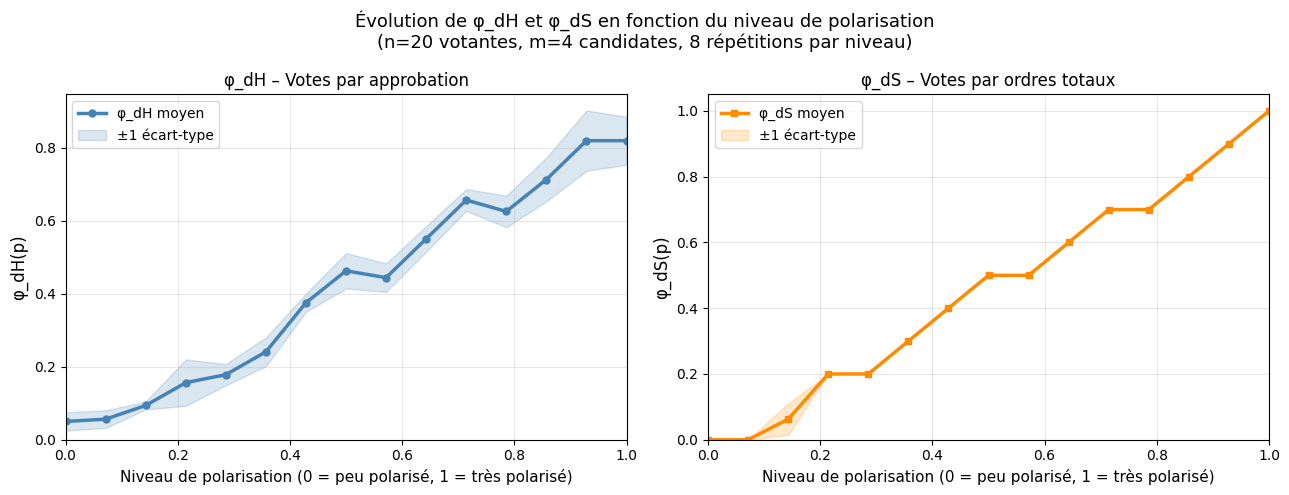

Figure sauvegardée : phi_dH_dS_evolution.png


In [15]:
# ── Tracé des courbes φ_dH et φ_dS ──

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(
    f"Évolution de φ_dH et φ_dS en fonction du niveau de polarisation\n"
    f"(n={N} votantes, m={M} candidates, {N_REPEAT} répétitions par niveau)",
    fontsize=13
)

# ── Axe gauche : φ_dH (approbation) ──
ax1 = axes[0]
ax1.plot(pol_levels, phi_dH_mean, color='steelblue', linewidth=2.5,
         marker='o', markersize=5, label='φ_dH moyen')
ax1.fill_between(pol_levels,
                 phi_dH_mean - phi_dH_std,
                 phi_dH_mean + phi_dH_std,
                 alpha=0.2, color='steelblue', label='±1 écart-type')
ax1.set_xlabel('Niveau de polarisation (0 = peu polarisé, 1 = très polarisé)', fontsize=11)
ax1.set_ylabel('φ_dH(p)', fontsize=12)
ax1.set_title('φ_dH – Votes par approbation', fontsize=12)
ax1.set_xlim(0, 1)
ax1.set_ylim(bottom=0)
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# ── Axe droit : φ_dS (ordres totaux) ──
ax2 = axes[1]
ax2.plot(pol_levels, phi_dS_mean, color='darkorange', linewidth=2.5,
         marker='s', markersize=5, label='φ_dS moyen')
ax2.fill_between(pol_levels,
                 phi_dS_mean - phi_dS_std,
                 phi_dS_mean + phi_dS_std,
                 alpha=0.2, color='darkorange', label='±1 écart-type')
ax2.set_xlabel('Niveau de polarisation (0 = peu polarisé, 1 = très polarisé)', fontsize=11)
ax2.set_ylabel('φ_dS(p)', fontsize=12)
ax2.set_title('φ_dS – Votes par ordres totaux', fontsize=12)
ax2.set_xlim(0, 1)
ax2.set_ylim(bottom=0)
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('phi_dH_dS_evolution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure sauvegardée : phi_dH_dS_evolution.png")

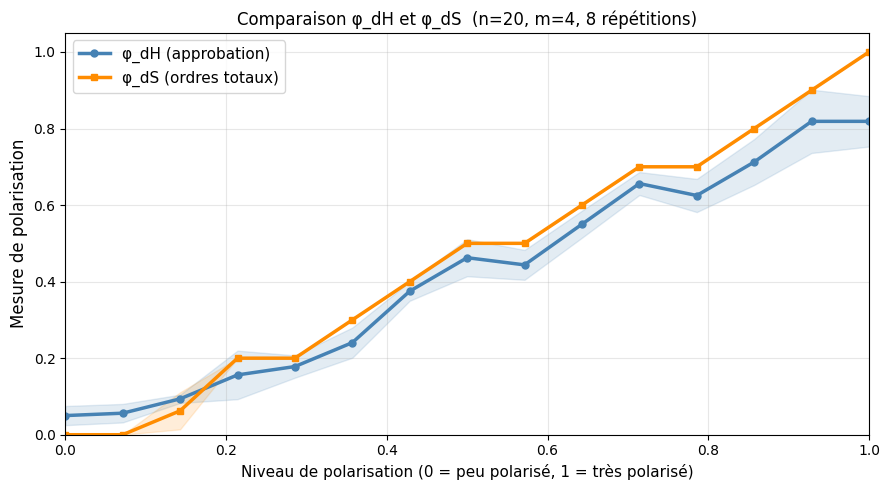

Figure sauvegardée : phi_dH_dS_comparison.png


In [16]:
# ── Graphe comparatif : φ_dH et φ_dS sur le même axe ──

fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(pol_levels, phi_dH_mean, color='steelblue', linewidth=2.5,
        marker='o', markersize=5, label='φ_dH (approbation)')
ax.fill_between(pol_levels, phi_dH_mean - phi_dH_std, phi_dH_mean + phi_dH_std,
                alpha=0.15, color='steelblue')

ax.plot(pol_levels, phi_dS_mean, color='darkorange', linewidth=2.5,
        marker='s', markersize=5, label='φ_dS (ordres totaux)')
ax.fill_between(pol_levels, phi_dS_mean - phi_dS_std, phi_dS_mean + phi_dS_std,
                alpha=0.15, color='darkorange')

ax.set_xlabel('Niveau de polarisation (0 = peu polarisé, 1 = très polarisé)', fontsize=11)
ax.set_ylabel('Mesure de polarisation', fontsize=12)
ax.set_title(
    f'Comparaison φ_dH et φ_dS  (n={N}, m={M}, {N_REPEAT} répétitions)',
    fontsize=12
)
ax.set_xlim(0, 1)
ax.set_ylim(bottom=0)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('phi_dH_dS_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure sauvegardée : phi_dH_dS_comparison.png")

---
## Interprétation des résultats

**Ce qu'on observe :**

- Quand `polarization → 0` (profil très polarisé, ressemblant à `p_{a, ā}`) :
  - `u*1` est élevé : un seul centre ne représente pas bien l'électorat divisé en deux camps.
  - `u*2` est bas : deux centres (un par camp) capturent parfaitement la structure.
  - La différence `u*1 - u*2` est grande → **φ_dH et φ_dS sont élevées**. ✓

- Quand `polarization → 1` (profil peu polarisé, ressemblant à `p_a`) :
  - `u*1` est bas : un seul centre suffit.
  - `u*2` apporte peu de gain supplémentaire.
  - La différence `u*1 - u*2` est faible → **φ_dH et φ_dS sont proches de 0**. ✓

**Comportement attendu des courbes :**
- Monotone décroissante de gauche (polarisé) vers droite (uniforme).
- La bande grisée (±1 écart-type) est plus large pour les niveaux intermédiaires
  (les profils y sont moins déterministes).

**Différence entre φ_dH et φ_dS :**
- φ_dS est normalisée par `m²` au lieu de `m` → valeurs typiquement plus petites.
- Les deux mesures capturent la même tendance qualitative.